# Support Vector Machine (SVM)

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [47]:
## Lets create synthetic datapoints
from sklearn.datasets import make_classification

In [48]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0, random_state=4)
y[:5]

array([1, 1, 1, 1, 1])

In [49]:
X=pd.DataFrame(X)
X.head()

,0,1
0,1.225160,-0.951731
1,1.016304,-1.725175
2,0.335340,-1.724896
3,1.786348,-1.782653
4,1.016751,1.062569


<Axes: xlabel='0', ylabel='1'>

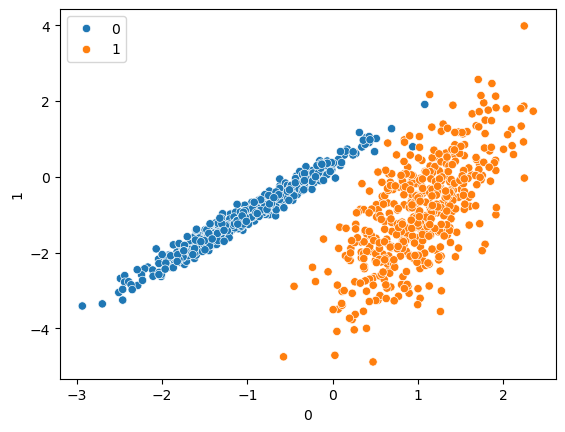

In [50]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

We can use SVC to classify this data. The kernel will be linear

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [52]:
from sklearn.svm import SVC

svc=SVC(kernel='linear')
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [53]:
## Predictio

y_pred=svc.predict(X_test)

In [54]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

1.0
[[123   0]
 [  0 127]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       1.00      1.00      1.00       127

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



### Other Kernels

When the data points cannot be linearly separable we use other kernels like RBF, Sigmoid or Polynomial 




#### **RBF kernel**

In [55]:
## create a binary classification dataset with multiple clusters

X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0, random_state=33)
y[:5]

array([1, 0, 0, 0, 1])

In [56]:
X=pd.DataFrame(X)
X.head()

,0,1
0,-1.125785,0.890510
1,-0.964564,-1.461033
2,2.726490,0.243033
3,-0.641874,-0.257132
4,1.007173,0.989763


<Axes: xlabel='0', ylabel='1'>

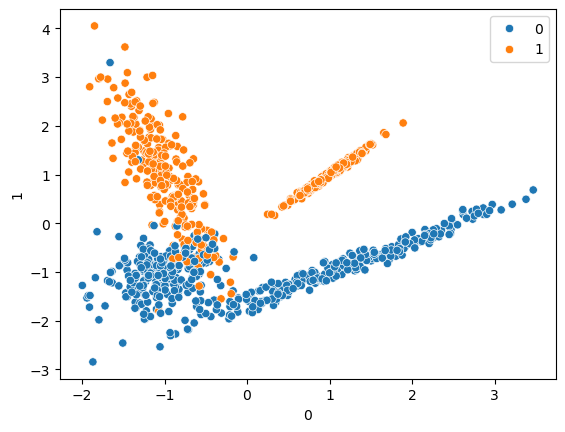

In [57]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [61]:
from sklearn.svm import SVC

rbf=SVC(kernel='rbf')
rbf.fit(X_train,y_train)

SVC()

In [62]:
y_pred=rbf.predict(X_test)

In [63]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.94
[[121   5]
 [ 10 114]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       126
           1       0.96      0.92      0.94       124

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



#### **Polynomial Kernel**

In [65]:
polynomial=SVC(kernel='poly')
polynomial.fit(X_train,y_train)

SVC(kernel='poly')

In [66]:
y_pred2=polynomial.predict(X_test)

score=accuracy_score(y_test,y_pred2)
print(score)
cm=confusion_matrix(y_test,y_pred2)
print(cm)
print(classification_report(y_test,y_pred2))

0.948
[[119   7]
 [  6 118]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       126
           1       0.94      0.95      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



#### **Sigmoid Kernel***

In [67]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)

SVC(kernel='sigmoid')

In [69]:
y_pred3=sigmoid.predict(X_test)

score=accuracy_score(y_test,y_pred3)
print(score)
cm=confusion_matrix(y_test,y_pred3)
print(cm)
print(classification_report(y_test,y_pred3))

0.92
[[119   7]
 [ 13 111]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       126
           1       0.94      0.90      0.92       124

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250



### Performing Hyperparameter Tuning 

Based on the models created Polynomial kernel gave us the best performance. We will perform some hyperparameter tuning to see if we can improve the model performance.

In [73]:
from sklearn.model_selection import GridSearchCV

## defining parameter range
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['poly']}

In [74]:
grid=GridSearchCV(SVC(),param_grid=param_grid,cv=5,verbose=3,refit=True)

In [75]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.960 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.960 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.933 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.960 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.953 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.727 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.667 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.720 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.673 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.713 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.01, kernel=poly;, score=0.540 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.01, kernel=poly

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['poly']},
             verbose=3)

In [76]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'poly'}

In [77]:
grid.best_score_

0.9560000000000001

In [78]:
y_pred_grid=grid.predict(X_test)

score=accuracy_score(y_test,y_pred_grid)
print(score)
cm=confusion_matrix(y_test,y_pred_grid)
print(cm)
print(classification_report(y_test,y_pred_grid))

0.952
[[119   7]
 [  5 119]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       126
           1       0.94      0.96      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



Notice It improved from 0.948 to 0.952